TensorFlow: 2.20.0
GPU: none - Runtime > Change runtime type > T4 GPU
No real dataset found -> using SYNTHETIC demo data (results are only a pipeline test).
Classes: ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Normal']
Images per class: {'AMD': 120, 'Cataract': 120, 'Diabetic_Retinopathy': 120, 'Glaucoma': 120, 'Normal': 120}
train=420  val=90  test=90


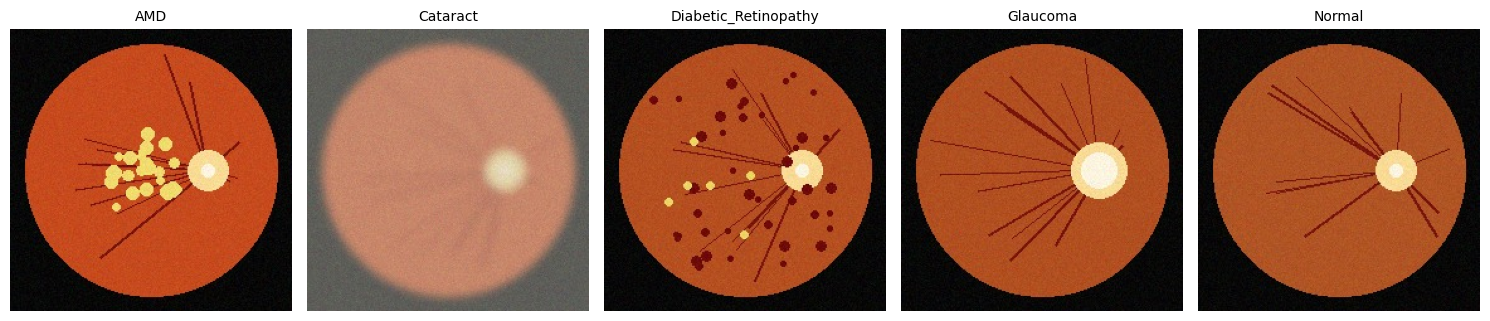

Class weights: {'AMD': 1.0, 'Cataract': 1.0, 'Diabetic_Retinopathy': 1.0, 'Glaucoma': 1.0, 'Normal': 1.0}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 2,264,389
Epoch 1/8
14/14 - 46s - 3s/step - accuracy: 0.5167 - loss: 1.2823 - val_accuracy: 0.8556 - val_loss: 0.6251 - learning_rate: 0.0010
Epoch 2/8
14/14 - 37s - 3s/step - accuracy: 0.8357 - loss: 0.5076 - val_accuracy: 0.9222 - val_loss: 0.3572 - learning_rate: 0.0010
Epoch 3/8
14/14 - 28s - 2s/step - accuracy: 0.8881 - loss: 0.3452 - val_accuracy: 0.9556 - val_loss: 0.2520 - learning_rate: 0.0010
Epoch 4/8
14/14 - 34s - 2s/step - accuracy: 0.9286 - loss: 0.2342 - val_accuracy: 0.9667 - val_loss: 0.2073 - learning_rate: 0.0010
Epoch 5/8
14/14 - 38s - 3s/step - accuracy: 0.9571 - loss: 0.1968 - val_accuracy: 0.9889 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 6/8
14/14 - 38s - 3s/step - accuracy: 0.9714 - loss: 0.1430 - val_accuracy: 0.9556 - val_loss: 0.1814 - learning_rate: 0.0010
Epoch 7/8
14/14 - 44s - 3

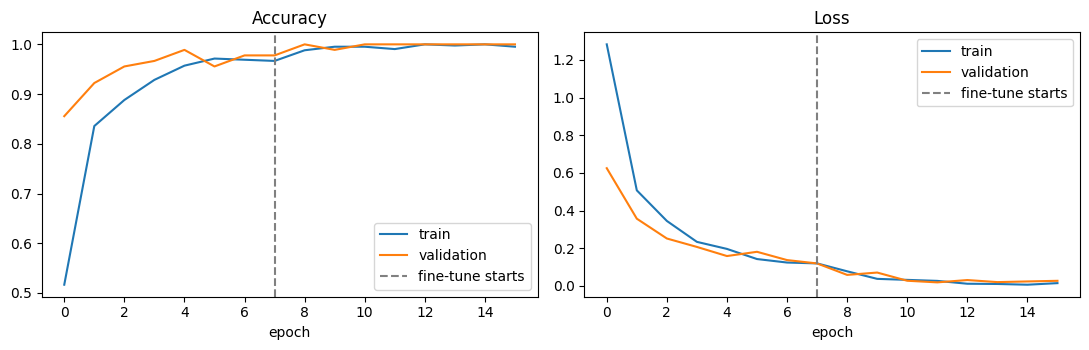

                      precision    recall  f1-score   support

                 AMD       1.00      1.00      1.00        18
            Cataract       1.00      1.00      1.00        18
Diabetic_Retinopathy       1.00      1.00      1.00        18
            Glaucoma       1.00      0.94      0.97        18
              Normal       0.95      1.00      0.97        18

            accuracy                           0.99        90
           macro avg       0.99      0.99      0.99        90
        weighted avg       0.99      0.99      0.99        90

Macro ROC-AUC: 1.0


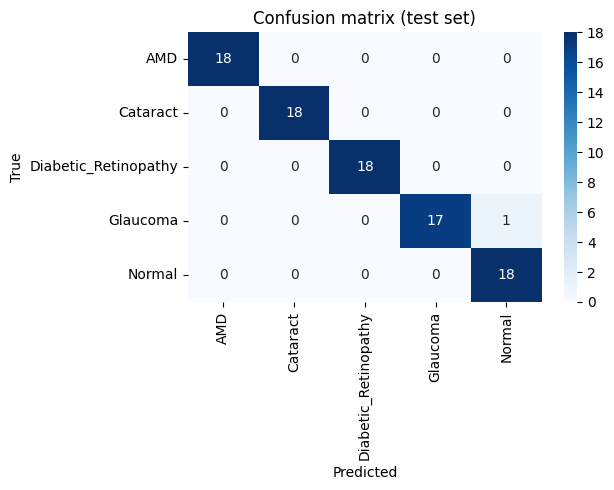

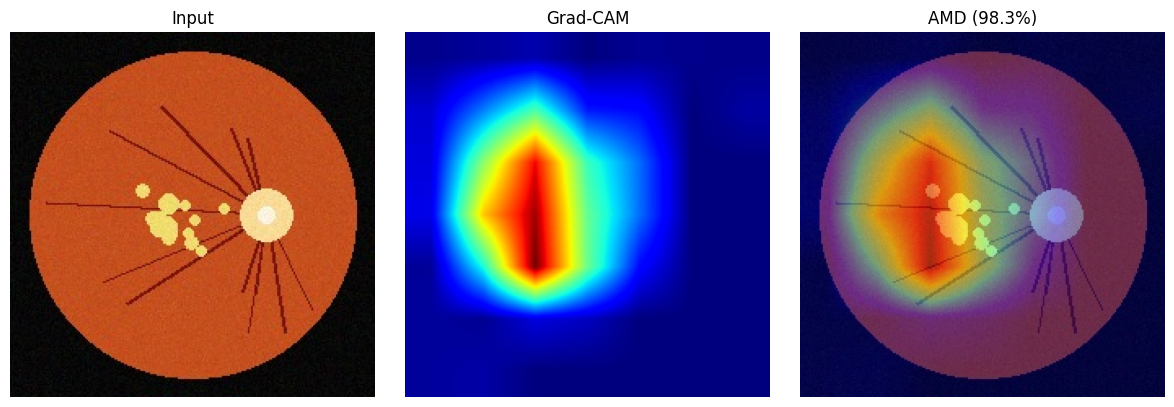

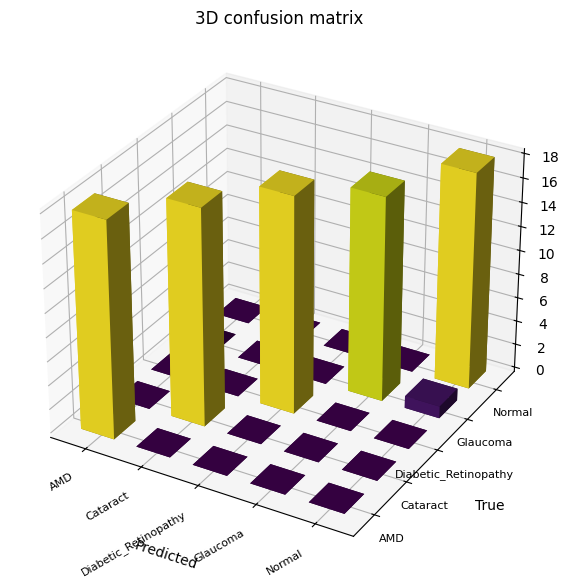

Saved artifact at '/tmp/tmpd92weldq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138452115707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115708560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115713552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115714512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115706448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115713744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115715088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115714896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115715280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138452115706256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1384521157

  AMD                    100.0%
  Diabetic_Retinopathy     0.0%
  Normal                   0.0%
Prediction: AMD

NOTE: EyeScan is a screening aid for a hackathon prototype, not a medical diagnosis.


In [ ]:
#LIBRARY / IMPORT SECTION >> “First, this section contains the libraries required for our project. NumPy is used for numerical operations, Matplotlib is used to display images and graphs, and TensorFlow with Keras provides the deep-learning framework. These libraries give us the tools needed for image preparation, model building, training and prediction.”
#Each library has a specific role. NumPy handles numerical data, Matplotlib helps with visualization, and TensorFlow/Keras is used to build and run the deep-learning model.”
import os, glob, random, shutil, zipfile, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
import plotly.graph_objects as go
import plotly.io as pio
from PIL import Image, ImageDraw, ImageFilter

warnings.filterwarnings("ignore")
try:
    pio.renderers.default = "colab"
except Exception:
    pass
    #Setup and reproducibility >> “First, we import tools like TensorFlow for deep learning, NumPy for data handling, and PIL for image operations. We also set a random seed so experiments are more repeatable.”
    #SEED=42 fixes random-number behavior where possible. IMG_SIZE makes each image 224×224 pixels; BATCH=32 processes 32 images per training step. A seed improves repeatability, but does not guarantee identical results on every device.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus if gpus else "none - Runtime > Change runtime type > T4 GPU")
IMG_SIZE = 224
BATCH = 32
EPOCHS_HEAD = 8
EPOCHS_FINE = 8
LR_HEAD = 1e-3
LR_FINE = 1e-5
FINE_TUNE_LAYERS = 30

DATA_DIR = "/content/eye_dataset"
DATASET_ZIP = "/content/eye_dataset.zip"
DEMO_DIR = "/content/demo_eye_dataset"
OUT_DIR = "/content/eyescan_output"
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")
os.makedirs(OUT_DIR, exist_ok=True)

def find_root(path):
    """Step inside wrapper folders until we reach the folder that holds the class folders."""
    while True:
        items = [d for d in os.listdir(path) if not d.startswith((".", "__"))]
        subs = [d for d in items if os.path.isdir(os.path.join(path, d))]
        files = [f for f in items if f.lower().endswith(IMG_EXT)]
        if len(subs) == 1 and not files:
            path = os.path.join(path, subs[0])
        else:
            return path

#Dataset and class labels >> “Next, the notebook checks whether a real image dataset is available. It organizes image paths and labels by folder. If a real dataset is missing, it creates synthetic demo retina-like images for five example classes.”
#Each class is represented by a folder name. Important: the fallback images are computer-generated illustrations, not real clinical photographs. The notebook itself says results in demo mode are only a pipeline test.

def dataset_ready(path):
    if not os.path.isdir(path):
        return False
    root = find_root(path)
    classes = [d for d in os.listdir(root)
               if os.path.isdir(os.path.join(root, d)) and not d.startswith((".", "__"))]
    n_img = sum(1 for c in classes for f in os.listdir(os.path.join(root, c))
                if f.lower().endswith(IMG_EXT))
    return len(classes) >= 2 and n_img >= 20


def make_fundus(cls, size=224, rng=None):
    """Draw one synthetic retina-like image with a class-specific pattern."""
    rng = rng or np.random.default_rng()
    img = Image.new("RGB", (size, size), (8, 8, 8))
    d = ImageDraw.Draw(img)
    m, cx, cy = 12, size // 2, size // 2
    base = (int(190 + rng.integers(-15, 15)), int(80 + rng.integers(-10, 10)),
            int(35 + rng.integers(-8, 8)))
    d.ellipse([m, m, size - m, size - m], fill=base)
    for _ in range(14):
        a, r = rng.uniform(0, 2 * np.pi), rng.uniform(40, 95)
        d.line([cx + 45, cy, cx + np.cos(a) * r, cy + np.sin(a) * r],
               fill=(120, 20, 15), width=int(rng.integers(1, 3)))
    disc_r, cup_r = 16, 5
    if cls == "Glaucoma":
        disc_r, cup_r = 22, 14
    d.ellipse([cx + 45 - disc_r, cy - disc_r, cx + 45 + disc_r, cy + disc_r], fill=(250, 220, 150))
    d.ellipse([cx + 45 - cup_r, cy - cup_r, cx + 45 + cup_r, cy + cup_r], fill=(255, 245, 225))
    if cls == "Diabetic_Retinopathy":
        for _ in range(int(rng.integers(25, 45))):
            x, y, r = rng.integers(35, size - 35), rng.integers(35, size - 35), int(rng.integers(2, 5))
            d.ellipse([x - r, y - r, x + r, y + r], fill=(110, 10, 10))
        for _ in range(6):
            x, y = rng.integers(45, size - 45), rng.integers(45, size - 45)
            d.ellipse([x - 3, y - 3, x + 3, y + 3], fill=(235, 215, 100))
    if cls == "AMD":
        for _ in range(int(rng.integers(15, 26))):
            x, y = cx - 10 + rng.normal(0, 14), cy + rng.normal(0, 14)
            r = int(rng.integers(3, 7))
            d.ellipse([x - r, y - r, x + r, y + r], fill=(240, 220, 110))
    if cls == "Cataract":
        img = img.filter(ImageFilter.GaussianBlur(3.5))
        img = Image.blend(img, Image.new("RGB", (size, size), (200, 200, 190)), 0.45)
    arr = np.asarray(img, dtype=np.float32) + rng.normal(0, 6, (size, size, 3))
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def make_demo_dataset(root, n_per_class=120):
    rng = np.random.default_rng(SEED)
    for cls in ["Normal", "Diabetic_Retinopathy", "Glaucoma", "Cataract", "AMD"]:
        os.makedirs(os.path.join(root, cls), exist_ok=True)
        for i in range(n_per_class):
            out = os.path.join(root, cls, f"{cls}_{i:03d}.jpg")
            make_fundus(cls, IMG_SIZE, rng).save(out, quality=92)

if os.path.exists(DATASET_ZIP) and not dataset_ready(DATA_DIR):
    with zipfile.ZipFile(DATASET_ZIP) as z:
        z.extractall(DATA_DIR)

if dataset_ready(DATA_DIR):
    ROOT, DEMO_MODE = find_root(DATA_DIR), False
    print("Using REAL dataset:", ROOT)
else:
    if not dataset_ready(DEMO_DIR):
        make_demo_dataset(DEMO_DIR)
    ROOT, DEMO_MODE = find_root(DEMO_DIR), True
    print("No real dataset found -> using SYNTHETIC demo data (results are only a pipeline test).")

CLASS_NAMES = sorted(d for d in os.listdir(ROOT)
                     if os.path.isdir(os.path.join(ROOT, d)) and not d.startswith((".", "__")))
NUM_CLASSES = len(CLASS_NAMES)
paths, labels = [], []
for idx, c in enumerate(CLASS_NAMES):
    for f in sorted(os.listdir(os.path.join(ROOT, c))):
        if f.lower().endswith(IMG_EXT):
            paths.append(os.path.join(ROOT, c, f))
            labels.append(idx)
paths, labels = np.array(paths), np.array(labels)
print("Classes:", CLASS_NAMES)
print("Images per class:", dict(zip(CLASS_NAMES, np.bincount(labels).tolist())))

tr_p, tmp_p, tr_y, tmp_y = train_test_split(paths, labels, test_size=0.30, stratify=labels,
                                            random_state=SEED)
va_p, te_p, va_y, te_y = train_test_split(tmp_p, tmp_y, test_size=0.50, stratify=tmp_y,
                                          random_state=SEED)
print(f"train={len(tr_p)}  val={len(va_p)}  test={len(te_p)}")

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3.2))
axes = np.atleast_1d(axes)
for i, ax in enumerate(axes):
    ax.imshow(Image.open(paths[np.where(labels == i)[0][0]]).convert("RGB"))
    ax.set_title(CLASS_NAMES[i], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

AUTOTUNE = tf.data.AUTOTUNE


def _load(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    #Image preparation and splitting  //The code reads each image, converts it to three color channels, resizes it, and batches it for the model. Then it separates the data into training, validation, and testing sets.”
    #Resize creates a consistent input shape. The first split keeps 70% for training and 30% aside; that remaining portion is split equally into validation and test—approximately 70/15/15 overall. Stratify helps preserve class proportions.

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return tf.cast(img, tf.float32), tf.cast(label, tf.int32)


def make_ds(p, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if training:
        ds = ds.shuffle(len(p), seed=SEED, reshuffle_each_iteration=True)
    return ds.map(_load, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)


train_ds = make_ds(tr_p, tr_y, training=True)
val_ds = make_ds(va_p, va_y)
test_ds = make_ds(te_p, te_y)

cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=tr_y)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", {CLASS_NAMES[i]: round(w, 2) for i, w in class_weight.items()})

augment = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augment")

rescale = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="rescale")

try:
  #The AI model: MobileNetV2  //Our model uses MobileNetV2, a convolutional neural network first trained on ImageNet. We initially freeze its base layers and add a small classifier that outputs probabilities for our eye-image classes
  # Transfer learning reuses previously learned image features. GlobalAveragePooling summarizes feature maps; Dropout helps reduce overfitting; Dense with softmax returns a probability-like score for each class. These scores are not automatically medical confidence or a diagnosis.
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False,
                                             weights="imagenet", name="backbone")
except Exception as e:
    print("Could not download ImageNet weights, training from scratch instead:", e)
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False,
                                             weights=None, name="backbone")
base.trainable = False

gap = layers.GlobalAveragePooling2D(name="gap")
drop = layers.Dropout(0.3, name="drop")
dense = layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")

inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
x = augment(inputs)
x = rescale(x)
x = base(x, training=False)
x = gap(x)
x = drop(x)
outputs = dense(x)
model = models.Model(inputs, outputs, name="EyeScan_MobileNetV2")
print("Total parameters:", f"{model.count_params():,}")

def make_callbacks(tag):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
        callbacks.ModelCheckpoint(os.path.join(OUT_DIR, f"best_{tag}.keras"),
                                  monitor="val_loss", save_best_only=True),
    ]
#Training and fine-tuning  //We train the new classifier first, then unfreeze only the last 30 MobileNetV2 layers and fine-tune them with a smaller learning rate. Validation monitoring helps save the best checkpoint and reduce unnecessary training
#The notebook runs up to 8 head-training epochs and up to 8 fine-tuning epochs. Callbacks include early stopping, learning-rate reduction, and saving the best model. Class weights are also calculated to help address uneven class counts.

model.compile(optimizer=tf.keras.optimizers.Adam(LR_HEAD),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                  class_weight=class_weight, callbacks=make_callbacks("head"), verbose=2)

base.trainable = True
for layer in base.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(LR_FINE),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE,
                  class_weight=class_weight, callbacks=make_callbacks("finetune"), verbose=2)

hist = {k: hist1.history[k] + hist2.history[k] for k in hist1.history}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, key, name in zip(ax, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    a.plot(hist[key], label="train")
    a.plot(hist["val_" + key], label="validation")
    a.axvline(len(hist1.history[key]) - 1, color="gray", ls="--", label="fine-tune starts")
    a.set_title(name)
    a.set_xlabel("epoch")
    a.legend()
plt.tight_layout()
plt.show()
# Prediction, evaluation, and explanation  //Finally, the model predicts the test images. We compare predictions with the true labels using a classification report and confusion matrix. Grad-CAM creates a heatmap to show image regions that influenced the prediction, and we save the model for reuse
# argmax selects the class with the largest output score. The notebook also attempts ROC-AUC, plots a confusion matrix and Grad-CAM, and exports a TensorFlow Lite version. No measured accuracy value is included in the notebook source itself; report the actual run's test results only
probs = model.predict(test_ds, verbose=0)
y_pred = probs.argmax(axis=1)
print(classification_report(te_y, y_pred, labels=np.arange(NUM_CLASSES),
                            target_names=CLASS_NAMES, zero_division=0))
try:
    print("Macro ROC-AUC:", round(roc_auc_score(te_y, probs, multi_class="ovr",
                                                labels=np.arange(NUM_CLASSES)), 4))
except Exception as e:
    print("ROC-AUC skipped:", e)

cm = confusion_matrix(te_y, y_pred, labels=np.arange(NUM_CLASSES))
plt.figure(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

embed_model = models.Model(inputs, gap.output)
emb = embed_model.predict(test_ds, verbose=0)
pts = PCA(n_components=3, random_state=SEED).fit_transform(emb)

fig3d = go.Figure()
for i, name in enumerate(CLASS_NAMES):
    m = te_y == i
    fig3d.add_trace(go.Scatter3d(
        x=pts[m, 0], y=pts[m, 1], z=pts[m, 2], mode="markers", name=name,
        marker=dict(size=5, opacity=0.85, line=dict(width=0.5, color="white")),
        text=[os.path.basename(p) for p in te_p[m]], hoverinfo="text+name"))
fig3d.update_layout(title="EyeScan - 3D feature space (PCA)", height=650,
                    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
                    legend=dict(itemsizing="constant"))
fig3d.write_html(os.path.join(OUT_DIR, "eyescan_3d_feature_space.html"), include_plotlyjs="cdn")
fig3d.show()

def load_img(path):
    return np.asarray(Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32)


def gradcam(img, class_idx=None):
    x = tf.convert_to_tensor(img[None, ...], tf.float32)
    with tf.GradientTape() as tape:
        conv = base(rescale(x), training=False)
        tape.watch(conv)
        preds = dense(gap(conv))
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        score = preds[:, class_idx]
    grads = tape.gradient(score, conv)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(conv * weights[:, None, None, :], axis=-1)[0]
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy(), class_idx, preds.numpy()[0]


sample = te_p[0]
img = load_img(sample)
cam, cls_idx, pr = gradcam(img)
cam_big = tf.image.resize(cam[..., None], (IMG_SIZE, IMG_SIZE)).numpy()[..., 0]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img.astype(np.uint8))
ax[0].set_title("Input")
ax[1].imshow(cam_big, cmap="jet")
ax[1].set_title("Grad-CAM")
ax[2].imshow(img.astype(np.uint8))
ax[2].imshow(cam_big, cmap="jet", alpha=0.45)
ax[2].set_title(f"{CLASS_NAMES[cls_idx]} ({pr[cls_idx]*100:.1f}%)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

small = tf.image.resize(cam[..., None], (56, 56)).numpy()[..., 0]
surf = go.Figure(go.Surface(z=small, colorscale="Jet", showscale=True,
                            colorbar=dict(title="attention")))
surf.update_layout(title=f"3D attention surface - predicted: {CLASS_NAMES[cls_idx]}", height=600,
                   scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="attention",
                              aspectratio=dict(x=1, y=1, z=0.6)))
surf.write_html(os.path.join(OUT_DIR, "eyescan_3d_attention.html"), include_plotlyjs="cdn")
surf.show()

from mpl_toolkits.mplot3d import Axes3D
n = NUM_CLASSES
xs, ys = np.meshgrid(np.arange(n), np.arange(n))
xs, ys, zs = xs.ravel(), ys.ravel(), cm.ravel()
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.bar3d(xs, ys, np.zeros_like(zs), 0.6, 0.6, zs, shade=True,
         color=plt.cm.viridis(zs / max(zs.max(), 1)))
ax.set_xticks(np.arange(n) + 0.3)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
ax.set_yticks(np.arange(n) + 0.3)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Predicted", labelpad=14)
ax.set_ylabel("True", labelpad=14)
ax.set_zlabel("Images")
ax.set_title("3D confusion matrix")
plt.tight_layout()
plt.show()

model.save(os.path.join(OUT_DIR, "eyescan_model.keras"))
with open(os.path.join(OUT_DIR, "labels.json"), "w") as f:
    json.dump(CLASS_NAMES, f)

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(os.path.join(OUT_DIR, "eyescan_model.tflite"), "wb") as f:
        f.write(tflite_model)
    print(f"TFLite size: {len(tflite_model) / 1e6:.1f} MB")
except Exception as e:
    print("TFLite export skipped:", e)

shutil.make_archive("/content/eyescan_output", "zip", OUT_DIR)
print("Saved everything to", OUT_DIR, "and /content/eyescan_output.zip")
print("Files:", os.listdir(OUT_DIR))

def predict_image(path):
    img = load_img(path)
    p = model.predict(img[None, ...], verbose=0)[0]
    order = np.argsort(p)[::-1]
    for i in order[:3]:
        print(f"  {CLASS_NAMES[i]:<22} {p[i] * 100:5.1f}%")
    return CLASS_NAMES[order[0]]


print("Test image:", os.path.basename(te_p[1]))
print("Prediction:", predict_image(te_p[1]))

print("\nNOTE: EyeScan is a screening aid for a hackathon prototype, not a medical diagnosis.")

***Confidence LevelPercentage RangeData Reliability & Action Required:

🟢 Good (High)85% – 100%Excellent calibration. The system has a clear lock on the pupil and cornea. Data is highly reliable for research, gaming, or biometrics.

🟡 Medium (Moderate)60% – 84%Acceptable but unstable. The system can track the eyes, but minor disruptions are occurring. Usually fine for casual use, but needs improvement for precise tasks.

🔴 LowBelow 60%Unreliable data. Frequent loss of tracking. The system cannot accurately determine where the eyes are looking. Requires immediate recalibration or troubleshooting.